In [1]:
import numpy as np
import serial
import time

# ================= CONFIG =================
SERIAL_PORT = "/dev/ttyACM0"          # Cambia por tu puerto (en Linux: /dev/ttyACM0)
BAUD = 115200                 # No importa realmente en USB CDC
MATRIX_FILE = "pcg_test_stm32.txt"   # Tu archivo txt (N líneas × 1024 floats)
OUTPUT_FILE = "matriz_abs.txt"

# Abrir puerto serial
ser = serial.Serial(SERIAL_PORT, BAUD, timeout=0.2, write_timeout=2)
print("Conectado a", SERIAL_PORT)

# Muchos STM32 se reinician al abrir /dev/ttyACM*
time.sleep(2.0)
ser.reset_input_buffer()
ser.reset_output_buffer()

HEADER = b'\xDE\xAD\xBE\xEF'
VECTOR_LEN = 1024
VECTOR_BYTES = VECTOR_LEN * 4

def read_exact(port, nbytes, timeout_s=3.0):
    """Lee exactamente nbytes o devuelve lo recibido si vence timeout."""
    deadline = time.monotonic() + timeout_s
    chunks = bytearray()
    while len(chunks) < nbytes and time.monotonic() < deadline:
        chunk = port.read(nbytes - len(chunks))
        if chunk:
            chunks.extend(chunk)
    return bytes(chunks)

# Cargar matriz (float32 exacto)
matrix = np.loadtxt(MATRIX_FILE, dtype=np.float32)

# Forzar forma 2D para el caso de un solo vector
a = np.atleast_2d(matrix)
matrix = a
if matrix.shape[1] != VECTOR_LEN:
    ser.close()
    raise ValueError(
        f"Formato invalido en {MATRIX_FILE}: se esperaban {VECTOR_LEN} columnas y llegaron {matrix.shape[1]}"
    )

N = matrix.shape[0]
print(f"Matriz cargada: {N} vectores de {VECTOR_LEN} floats")

# Buffer para recibir
result_matrix = np.zeros((N, VECTOR_LEN), dtype=np.float32)
resp_header = b""

processed = 0
error_msg = None

try:
    for i in range(N):
        vector = matrix[i]
        data = vector.tobytes()

        # Enviar header + datos
        ser.write(HEADER + data)
        ser.flush()

        # Esperar respuesta (header + payload)
        resp_header = read_exact(ser, len(HEADER), timeout_s=3.0)
        if len(resp_header) != len(HEADER):
            error_msg = f"timeout esperando header en vector {i} (recibidos {len(resp_header)} bytes)"
            print("ERROR:", error_msg)
            break

        if resp_header != HEADER:
            error_msg = f"header invalido en vector {i}: {resp_header!r}"
            print("ERROR:", error_msg)
            break

        resp_data = read_exact(ser, VECTOR_BYTES, timeout_s=3.0)
        if len(resp_data) != VECTOR_BYTES:
            error_msg = (
                f"payload incompleto en vector {i} "
                f"(recibidos {len(resp_data)} de {VECTOR_BYTES} bytes)"
            )
            print("ERROR:", error_msg)
            break

        result_matrix[i] = np.frombuffer(resp_data, dtype=np.float32, count=VECTOR_LEN)
        processed += 1
        print(f"Vector {i+1}/{N} procesado -> abs guardado")
finally:
    ser.close()
    print("Puerto serial cerrado")

if processed == 0:
    print("No se guardo archivo: no se recibieron vectores validos.")
elif processed < N:
    np.savetxt(OUTPUT_FILE, result_matrix[:processed], fmt='%.8e')
    print(f"Guardado parcial: {processed}/{N} vectores en {OUTPUT_FILE}")
else:
    np.savetxt(OUTPUT_FILE, result_matrix, fmt='%.8e')
    print(f"Listo! Archivo guardado: {OUTPUT_FILE}")

Conectado a /dev/ttyACM0
Matriz cargada: 350 vectores de 1024 floats
Vector 1/350 procesado -> abs guardado
Vector 2/350 procesado -> abs guardado
Vector 3/350 procesado -> abs guardado
Vector 4/350 procesado -> abs guardado
Vector 5/350 procesado -> abs guardado
Vector 6/350 procesado -> abs guardado
Vector 7/350 procesado -> abs guardado
Vector 8/350 procesado -> abs guardado
Vector 9/350 procesado -> abs guardado
Vector 10/350 procesado -> abs guardado
Vector 11/350 procesado -> abs guardado
Vector 12/350 procesado -> abs guardado
Vector 13/350 procesado -> abs guardado
Vector 14/350 procesado -> abs guardado
Vector 15/350 procesado -> abs guardado
Vector 16/350 procesado -> abs guardado
Vector 17/350 procesado -> abs guardado
Vector 18/350 procesado -> abs guardado
Vector 19/350 procesado -> abs guardado
Vector 20/350 procesado -> abs guardado
Vector 21/350 procesado -> abs guardado
Vector 22/350 procesado -> abs guardado
Vector 23/350 procesado -> abs guardado
Vector 24/350 proces

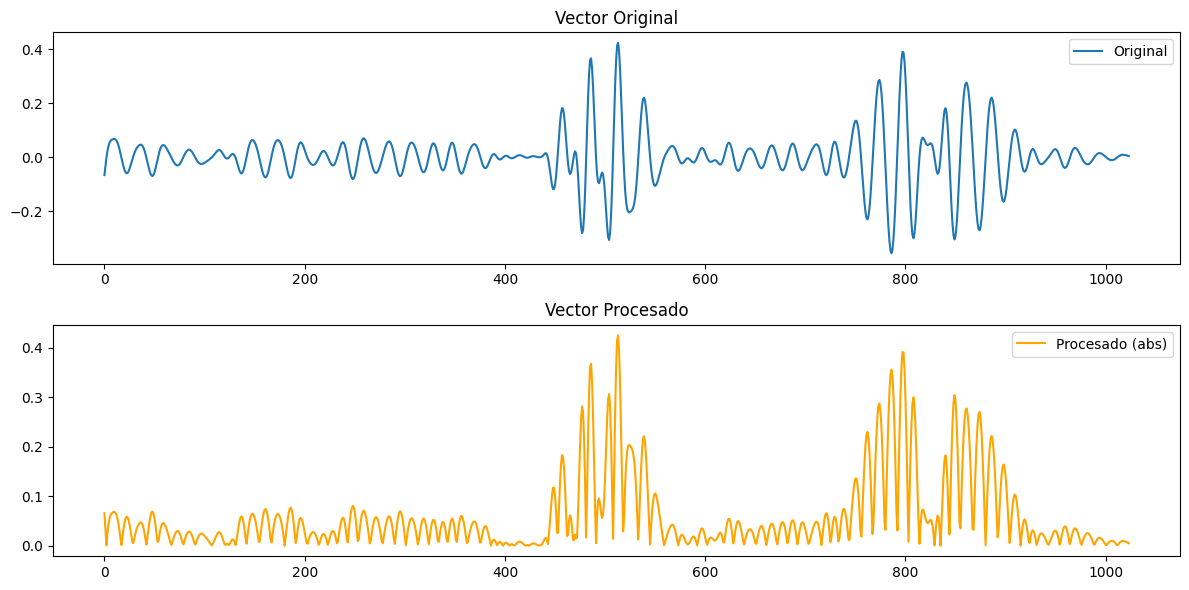

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(matrix[0], label='Original')
plt.title('Vector Original')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(result_matrix[0], label='Procesado (abs)', color='orange')
plt.title('Vector Procesado')
plt.legend()
plt.tight_layout()
plt.show()